In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn import metrics

from joblib import dump, load

In [5]:
data= pd.read_csv('D:\CSV_files\Real estate.csv')

In [6]:
data.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [7]:
data.shape

(414, 8)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


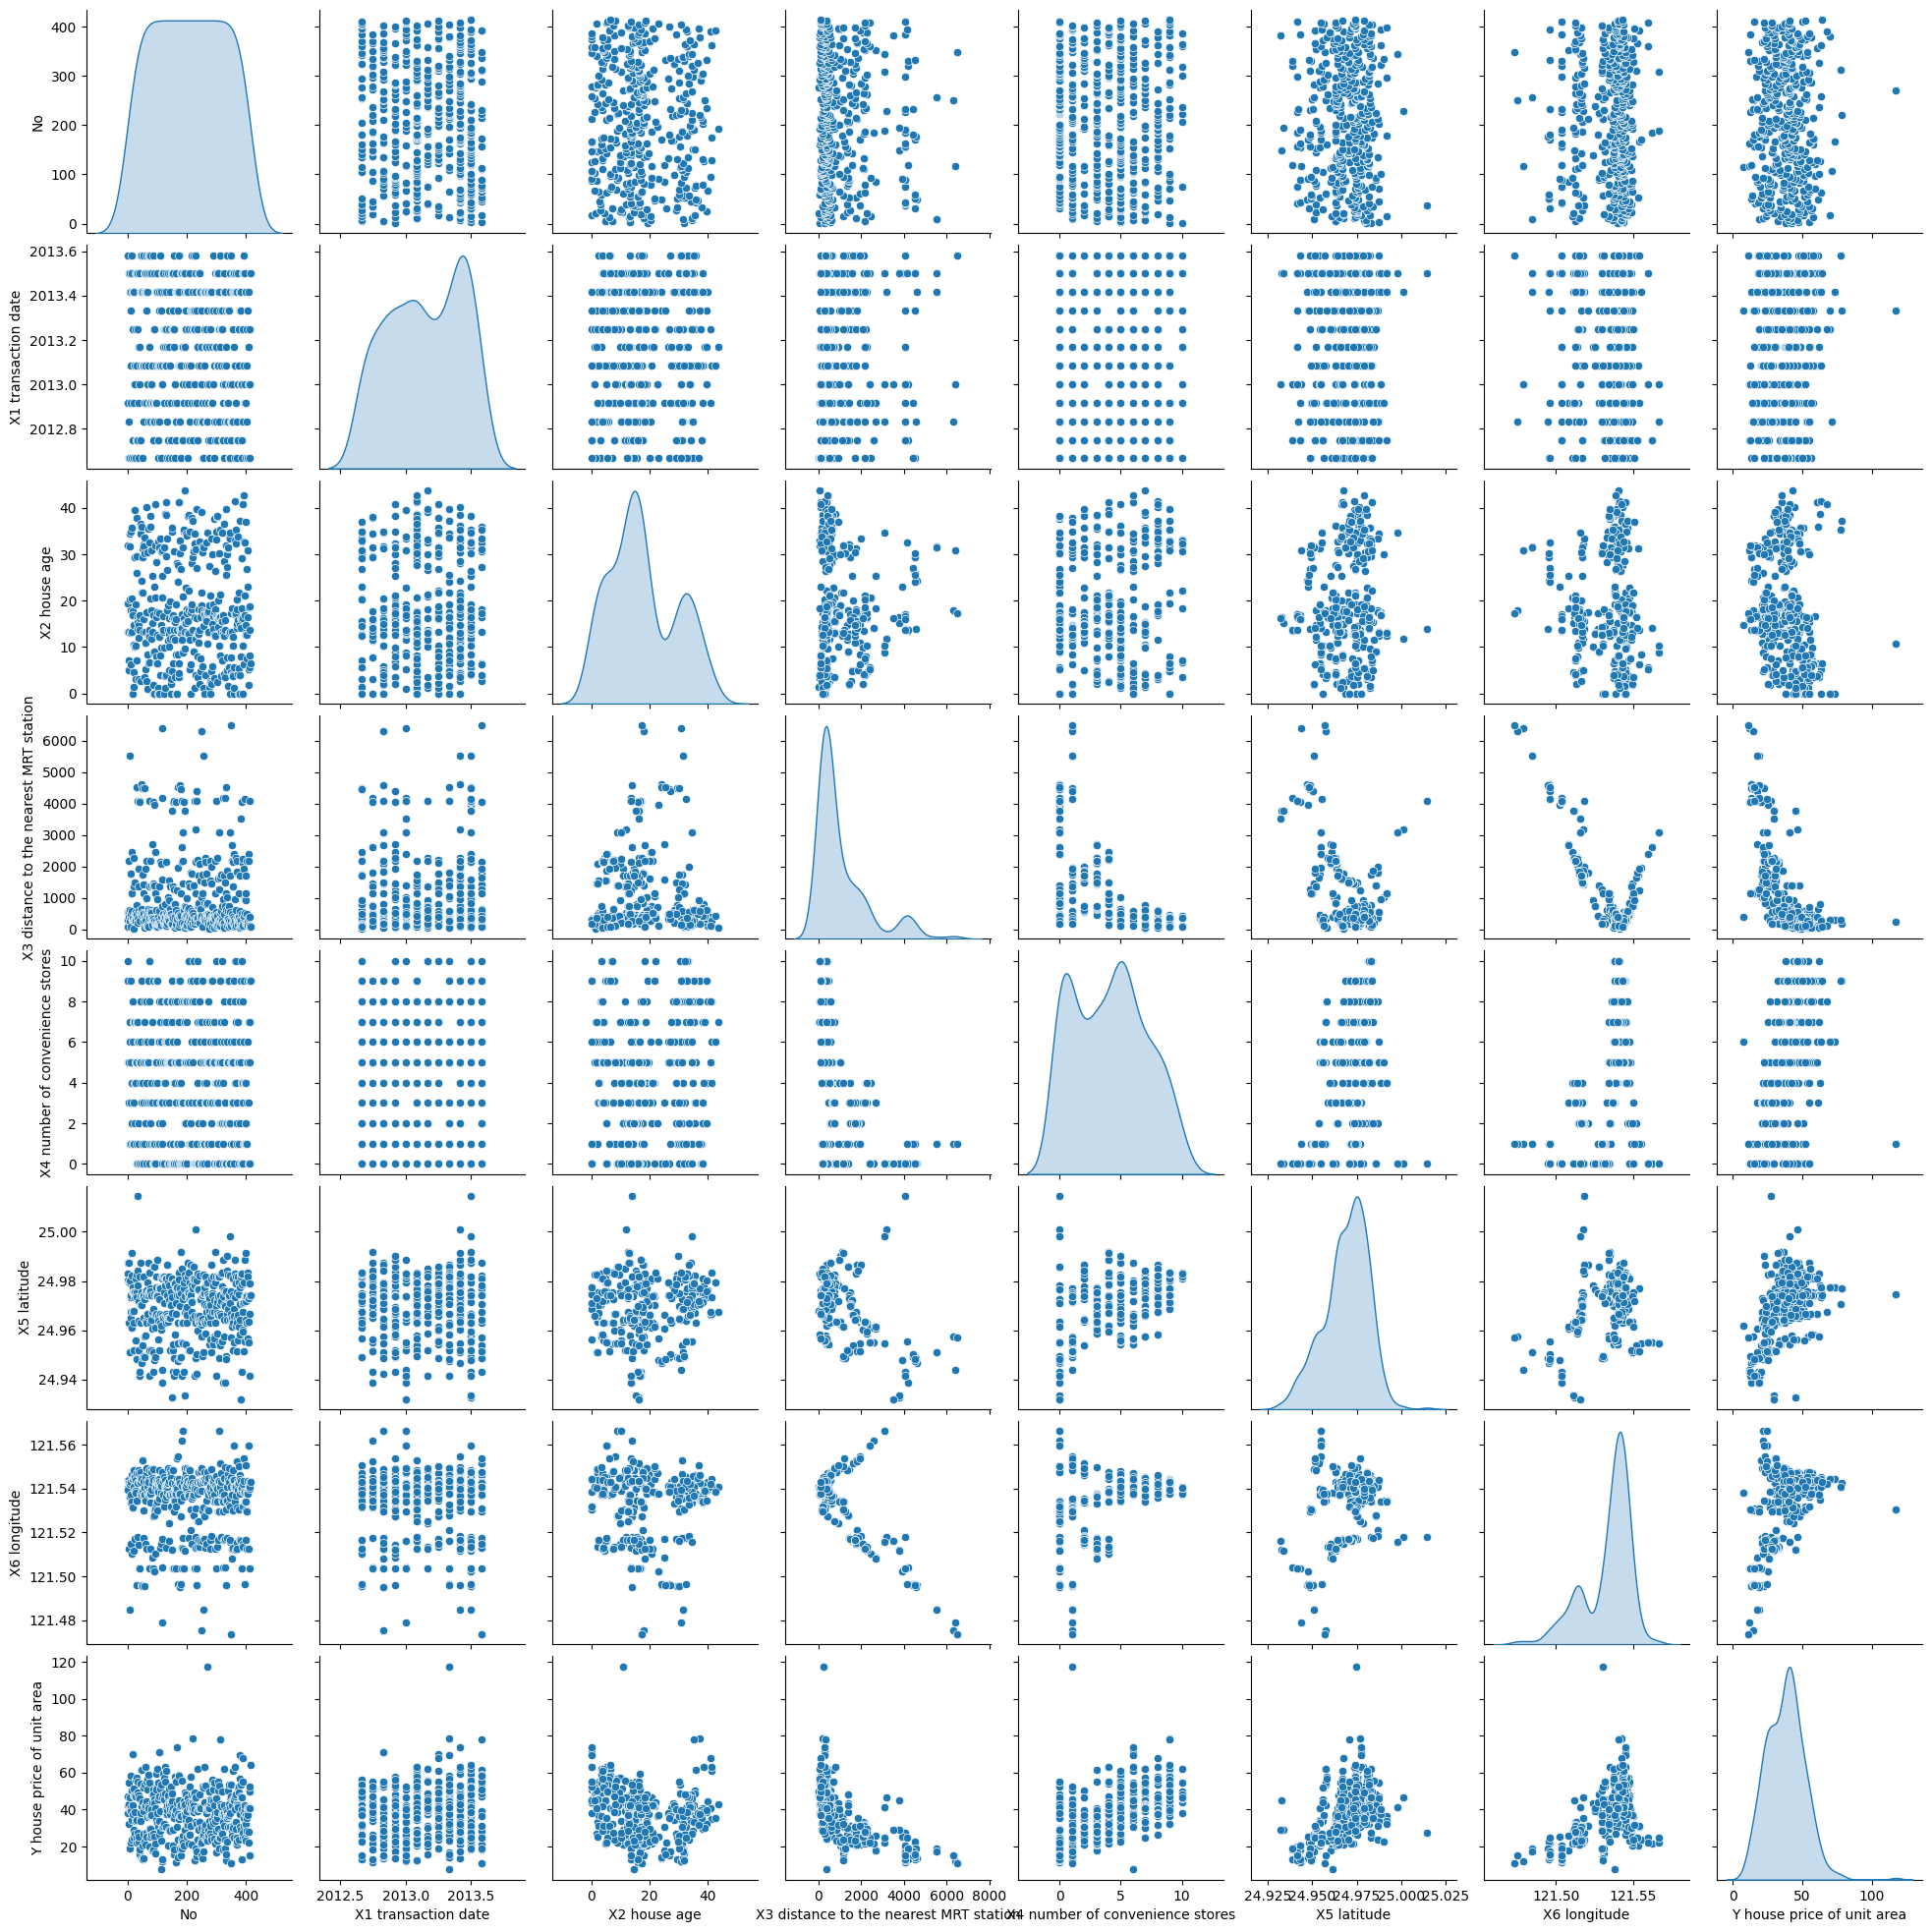

In [9]:
sns.pairplot(data, diag_kind='kde')

In [10]:
data.corr()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
No,1.000000,-0.048658,-0.032808,-0.013573,-0.012699,-0.010110,-0.011059,-0.028587
X1 transaction date,-0.048658,1.000000,0.017549,0.060880,0.009635,0.035058,-0.041082,0.087491
X2 house age,-0.032808,0.017549,1.000000,0.025622,0.049593,0.054420,-0.048520,-0.210567
X3 distance to the nearest MRT station,-0.013573,0.060880,0.025622,1.000000,-0.602519,-0.591067,-0.806317,-0.673613
X4 number of convenience stores,-0.012699,0.009635,0.049593,-0.602519,1.000000,0.444143,0.449099,0.571005
X5 latitude,-0.010110,0.035058,0.054420,-0.591067,0.444143,1.000000,0.412924,0.546307
X6 longitude,-0.011059,-0.041082,-0.048520,-0.806317,0.449099,0.412924,1.000000,0.523287
Y house price of unit area,-0.028587,0.087491,-0.210567,-0.673613,0.571005,0.546307,0.523287,1.000000


<Axes: >

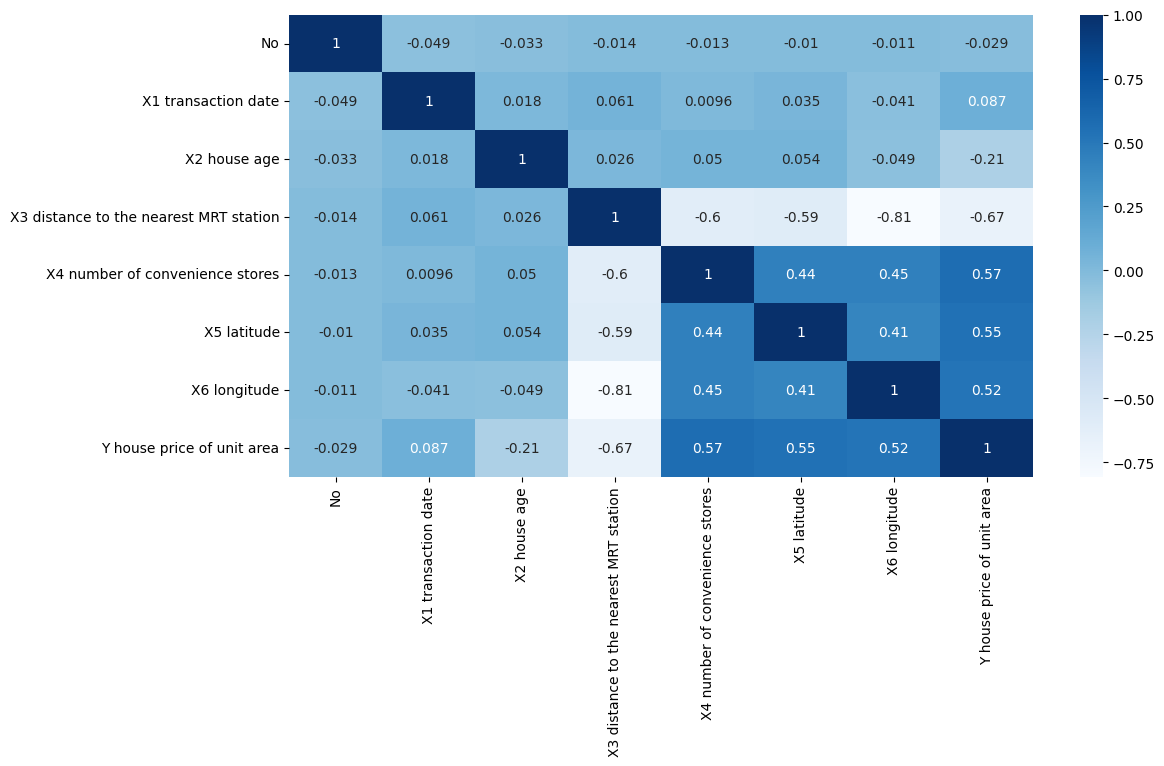

In [11]:
plt.subplots(figsize=(12, 6))
sns.heatmap(data.corr(), annot=True, cmap="Blues", )

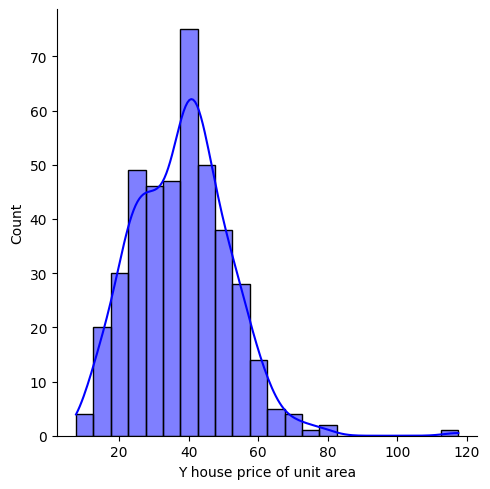

In [12]:
sns.displot(data=data, x='Y house price of unit area', kde=True, color='b')

In [13]:
X = data.drop('Y house price of unit area', axis=1)

y = data['Y house price of unit area']

In [14]:
polynomial_converter = PolynomialFeatures(degree=2, include_bias=False)

In [15]:
poly_features = polynomial_converter.fit_transform(X)

In [16]:
poly_features.shape

(414, 35)

In [17]:
X.shape

(414, 7)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)

In [19]:
polymodel = LinearRegression()

In [20]:
polymodel.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
y_pred = polymodel.predict(X_test)

In [22]:
pd.DataFrame({'Y_Test': y_test, 'Y_Pred': y_pred, 'Residuals':(y_test-y_pred)}).head(5)

,Y_Test,Y_Pred,Residuals
176,19.2,16.681999,2.518001
347,11.2,5.055940,6.144060
307,24.7,20.453657,4.246343
299,46.1,47.809931,-1.709931
391,31.3,28.199329,3.100671


In [23]:
Poly_MAE = metrics.mean_absolute_error(y_test, y_pred)
Poly_MSE = metrics.mean_squared_error(y_test, y_pred)
Poly_RMSE = np.sqrt(Poly_MSE)

pd.DataFrame([Poly_MAE, Poly_MSE, Poly_RMSE], index=['MAE', 'MSE', 'RMSE'], columns=['metrics'])

,metrics
MAE,4.465777
MSE,31.568270
RMSE,5.618565


In [24]:
XS_train, XS_test, ys_train, ys_test = train_test_split(X, y, test_size=0.3, random_state=101)
simplemodel = LinearRegression()
simplemodel.fit(XS_train, ys_train)
ys_pred = simplemodel.predict(XS_test)

MAE_simple = metrics.mean_absolute_error(ys_test, ys_pred)
MSE_simple = metrics.mean_squared_error(ys_test, ys_pred)
RMSE_simple = np.sqrt(MSE_simple)

In [25]:
pd.DataFrame({'Poly Metrics': [Poly_MAE, Poly_MSE, Poly_RMSE], 'Simple Metrics': [MAE_simple, MSE_simple, RMSE_simple]}, index = ['MAE', 'MSE', 'RMSE'])

,Poly Metrics,Simple Metrics
MAE,4.465777,5.373025
MSE,31.568270,45.880307
RMSE,5.618565,6.773500


In [26]:
train_RMSE_list = []

test_RSME_list = []

for d in range(1, 10):
    polynomial_converter = PolynomialFeatures(degree=d, include_bias=False)
    poly_features = polynomial_converter.fit(X)
    poly_features = polynomial_converter.transform(X)
    
    X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)
    
    polymodel = LinearRegression()
    polymodel.fit(X_train, y_train)
    
    y_train_pred = polymodel.predict(X_train)
    y_test_pred = polymodel.predict(X_test)
    
    train_RMSE = np.sqrt(metrics.mean_squared_error(y_train, y_train_pred))
    
    test_RSME = np.sqrt(metrics.mean_squared_error(y_test, y_test_pred))
    
    train_RMSE_list.append(train_RMSE)
    test_RSME_list.append(test_RSME)

In [27]:
pd.DataFrame({'Train RMSE List': train_RMSE_list})

,Train RMSE List
0,9.537107
1,8.051956
2,7.256683
3,6.164917
4,5.278492
5,5.352144
6,5.478648
7,5.863090
8,6.359515


In [28]:
pd.DataFrame({'Test RSME List': test_RSME_list})

,Test RSME List
0,6.773500
1,5.618565
2,9.259449
3,70.282090
4,128.746981
5,515.811929
6,13183.112384
7,14129.942000
8,15105.822768


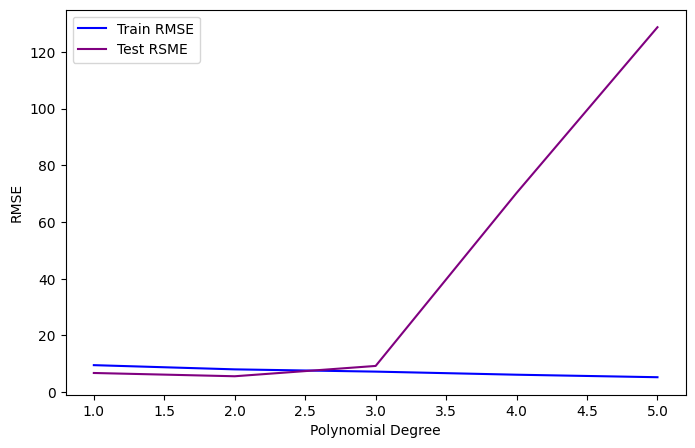

In [29]:
fig = plt.figure(figsize=(8,5))
plt.plot(range(1,6), train_RMSE_list[:5], label='Train RMSE', color="blue")
plt.plot(range(1,6), test_RSME_list[:5], label = 'Test RSME', color="purple")

plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.legend()
plt.show()

In [30]:
Final_polynomial_converter = PolynomialFeatures(degree=3, include_bias=False)

Final_poly_features = Final_polynomial_converter.fit(X)
Final_poly_features = Final_polynomial_converter.transform(X)

X_train, X_test, y_train, y_test = train_test_split(Final_poly_features, y, test_size=0.3, random_state=101)

Final_PolyModel = LinearRegression()
Final_PolyModel.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
dump(Final_PolyModel, 'Real_estate_PolyModel.joblib')

['Real_estate_PolyModel.joblib']

In [32]:
dump(Final_polynomial_converter, 'Poly_Converter.joblib')

['Poly_Converter.joblib']

In [33]:
Load_Converter = load('Poly_Converter.joblib')
Load_PolyModel = load('Real_estate_PolyModel.joblib')

In [35]:
campaign=[[1,2012.917,32.0,84.87882,10,24.98298,121.54024]]

In [36]:
campaign_poly = Load_Converter.transform(campaign)

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


In [37]:
Final_PolyModel.predict(campaign_poly)

array([39.65277215])

In [38]:
y_train[0]

np.float64(37.9)